# 10 Weighting comparison: form-letter double-counting

In [1]:

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

LABELS = "llm"

MAIN_CSV = "cleaned_comments_ver2.csv"
LLM_CSV  = "full_llm_UNIQUE.csv"
TOPICS = ["oil_spill_risk","climate_emissions","air_quality","environmental_justice",
          "marine_wildlife","fisheries","wetlands_coast","national_interest"]

main = pd.read_csv(MAIN_CSV, low_memory=False)
uniq = pd.read_csv(LLM_CSV, low_memory=False)

# LLM labels merged onto ALL rows by comment_text 
m = main.merge(uniq[["comment_text","llm_topics","llm_stance","llm_failed"]],
               on="comment_text", how="left")

if LABELS == "llm":
    for t in TOPICS:
        m[t+"_use"] = m["llm_topics"].fillna("").astype(str).apply(lambda s, t=t: t in s.split("|"))
    m["stance_use"] = m["llm_stance"].fillna("unclear").str.lower()
else:  # regex labels already in the main file
    for t in TOPICS:
        m[t+"_use"] = m[t].fillna(False).astype(bool)
    smap = {"Oppose":"oppose","Support":"support","Unclear":"unclear","Attachment only / unknown":"unclear"}
    m["stance_use"] = m["stance"].map(smap).fillna("unclear")

# three weightings
views = {
    "Weighted (by record)": m,
    "Dedup (exact)":        m.drop_duplicates("exact_form_letter_group"),
    "Dedup (template)":     m.drop_duplicates("template_family_id"),
}
for k, df in views.items():
    print(f"{k:22s} n = {len(df):>6,}")
print("labels =", LABELS)

Weighted (by record)   n = 10,195
Dedup (exact)          n =  6,551
Dedup (template)       n =  1,565
labels = llm


                view     n  oppose  support  unclear
Weighted (by record) 10195    91.5      1.4      7.1
       Dedup (exact)  6551    90.9      1.9      7.2
    Dedup (template)  1565    82.6      8.1      9.4


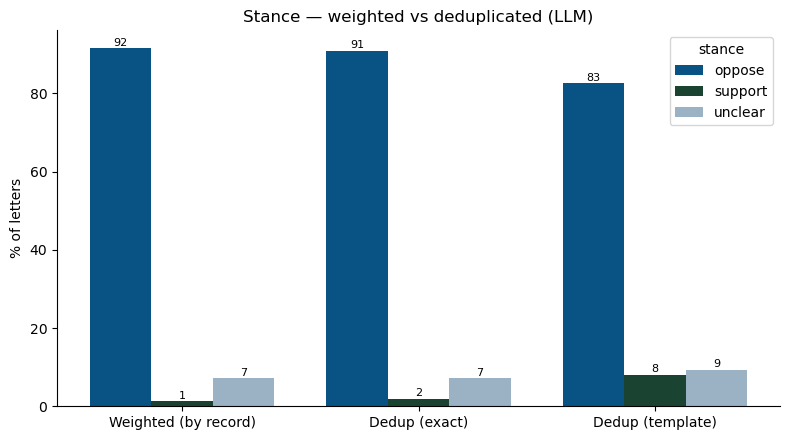

In [2]:

order  = ["oppose", "support", "unclear"]
colors = {"oppose": "#085384", "support": "#1B4332", "unclear": "#9bb1c4"}

tbl = []
for name, df in views.items():
    p = df["stance_use"].value_counts(normalize=True) * 100
    tbl.append({"view": name, "n": len(df), **{s: round(p.get(s, 0), 1) for s in order}})
print(pd.DataFrame(tbl).to_string(index=False))

x = np.arange(len(views)); w = 0.26
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, s in enumerate(order):
    vals = [(df["stance_use"].value_counts(normalize=True) * 100).get(s, 0) for df in views.values()]
    ax.bar(x + (i - 1) * w, vals, w, label=s, color=colors[s])
    for xi, v in zip(x + (i - 1) * w, vals):
        ax.text(xi, v + 0.6, f"{v:.0f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(list(views.keys()))
ax.set_ylabel("% of letters"); ax.set_title(f"Stance — weighted vs deduplicated ({LABELS.upper()})")
ax.legend(title="stance")
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.savefig(f"weighting_stance_{LABELS}.png", dpi=150, bbox_inches="tight"); plt.show()

                topic  Weighted (by record) n  Weighted (by record) %  Dedup (exact) n  Dedup (exact) %  Dedup (template) n  Dedup (template) %
       oil_spill_risk                    5784                    56.7             2964             45.2                 523                33.4
    climate_emissions                    9262                    90.8             5918             90.3                1256                80.3
          air_quality                    8626                    84.6             5347             81.6                 737                47.1
environmental_justice                    8806                    86.4             5525             84.3                 902                57.6
      marine_wildlife                    4154                    40.7             1301             19.9                 443                28.3
            fisheries                     937                     9.2              703             10.7                 185             

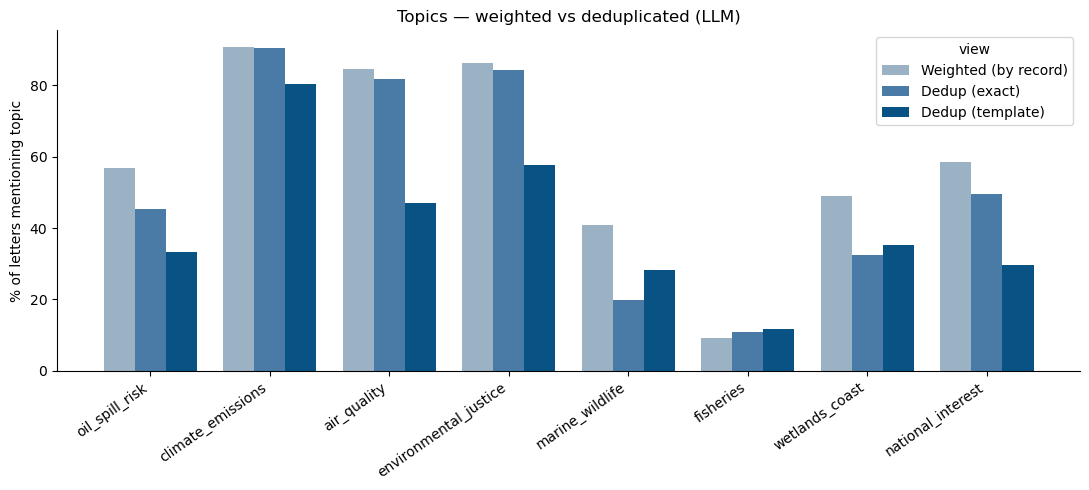

In [3]:
rows = []
for t in TOPICS:
    r = {"topic": t}
    for name, df in views.items():
        r[name + " n"] = int(df[t + "_use"].sum())
        r[name + " %"] = round(df[t + "_use"].mean() * 100, 1)
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False))

x = np.arange(len(TOPICS)); w = 0.26
vcolors = ["#9bb1c4", "#4a7ba6", "#085384"]
fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, df) in enumerate(views.items()):
    vals = [df[t + "_use"].mean() * 100 for t in TOPICS]
    ax.bar(x + (i - 1) * w, vals, w, label=name, color=vcolors[i])
ax.set_xticks(x); ax.set_xticklabels(TOPICS, rotation=35, ha="right")
ax.set_ylabel("% of letters mentioning topic")
ax.set_title(f"Topics — weighted vs deduplicated ({LABELS.upper()})")
ax.legend(title="view")
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.savefig(f"weighting_topics_{LABELS}.png", dpi=150, bbox_inches="tight"); plt.show()